# Item Prediction Using Graph Neuronal Networks

In this notebook we create a baseline for recommending items in a League of Legends match. 
The match extraction is similar as in the [GCNConv Edge Prediction Approach](graph_neural_networks_items_prediction_GCNConv_negative_sampling.ipynb). 
We stack all graph information (except the target player items) in a singed vector and predict the target player items using a simple linear network. 

In [1]:
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np
import random

import pandas as pd
import torch
import tqdm

from util.db.graph import Neo4JConnector

In [2]:
neo4j = Neo4JConnector.create_from_config("../config.ini")

random_state = 4201312
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed(random_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
input_classes = ["Champion", "Role", "Lane", "Item", "SummonerSpell"]
class_color_map = {x: plt.get_cmap("tab10")(i) for i,x in enumerate(input_classes)}

name_encodings = set()
name_type_map = {}
node_name_encodings_map = {}
node_type_map = {}

def create_encodings(node_type):
    res = neo4j.exec(f"MATCH (x:{node_type}) RETURN x")
    
    for r in res[0]:
        name = r["x"]["name"]
        name = f"{node_type}_{name}"
        name_encodings.add(name) 
        name_type_map[name] = node_type
        
        element_id = r["x"].element_id
        node_name_encodings_map[element_id] = name
        node_type_map[element_id] = node_type
        
for nt in input_classes:
    create_encodings(nt)

In [4]:
number_nodes = 10 + len(name_encodings)  # number players in a match
node_encodings = {x: 10 + i for i, x in enumerate(name_encodings)}
node_encodings_rev = {node_encodings[x]: x for x in node_encodings}
node_type_encodings = {x: i for i,x in enumerate(["Player"] + input_classes)}

In [5]:
nodes_matrix = torch.zeros((number_nodes, len(node_type_encodings))).type(torch.float32)
for i in range(10):
    nodes_matrix[i, node_type_encodings["Player"]] = 1
    
for node_element_id in node_name_encodings_map:
    node_name = node_name_encodings_map[node_element_id]
    object_type = node_type_map[node_element_id]
    object_encoding = node_encodings[node_name]
    object_type_encoding = node_type_encodings[object_type]
    nodes_matrix[object_encoding, object_type_encoding] = 1

In [6]:
def encode_match(match_id):
    match_query = f"""MATCH (m: Match {{matchID: $matchid}})-[co:CONSISTS_OF]->(q:Queue)<-[pi:PLAYS_IN]-(p:PlayerInMatch)-[x]->(y: ({'|'.join(input_classes)})) RETURN q, p, x, y"""
    result = neo4j.exec(match_query, matchid=match_id)
    
    input_vector = torch.zeros(number_nodes*10, dtype=torch.float32)
    result_vector = torch.zeros(number_nodes, dtype=torch.float32)
    
    player_encodings = {}
    num_player = 0
    
    for x in result[0]:
        player_id = x["p"].element_id
        target_id = x["y"].element_id
        
        if player_id not in player_encodings:
            player_encodings[player_id] = num_player
            num_player = num_player + 1
        
        player_encoding = player_encodings[player_id]
        object_name = node_name_encodings_map[target_id]
        object_type = node_type_map[target_id]
        object_encoding = node_encodings[object_name]
        
        if player_encodings[player_id] == 0 and object_type == "Item":
            result_vector[object_encoding] = 1
        else:
            input_vector[player_encoding * number_nodes + object_encoding] = 1
    
    return input_vector, result_vector

In [7]:
def get_matches(limit = None):
    matches_query = """MATCH (m:Match) 
        WHERE m.gameType = "MATCHED_GAME" AND m.gameMode = "CLASSIC" AND 
            apoc.date.parse(toString(m.gameDuration), 's', 'HH:mm:ssX') > 1800
        RETURN m"""
    
    if limit is not None:
        matches_query = matches_query + " LIMIT " + str(limit)
    
    matches_encoded = []
    for match in tqdm.tqdm([x["m"]["matchID"] for x in neo4j.exec(matches_query)[0]]):
        encoded_match = encode_match(match)
        
        if encoded_match[1].sum() < 7:
            continue
        
        matches_encoded.append(encoded_match)
    
    return matches_encoded
    
matches = get_matches(5000)

100%|██████████| 5000/5000 [02:22<00:00, 35.14it/s]


In [8]:
matches_train, matches_test_validation = train_test_split(matches, train_size=0.8, random_state=random_state)
matches_test, matches_validation = train_test_split(matches_test_validation, train_size=0.5, random_state=random_state)

print(f"Train: {len(matches_train)}, Test: {len(matches_test)}, Validation: {len(matches_validation)}")

Train: 3800, Test: 475, Validation: 475


In [9]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(matches_train, batch_size=32, shuffle=True)
test_dataloader = DataLoader(matches_test, batch_size=32, shuffle=True)
validation_dataloader = DataLoader(matches_validation, batch_size=32, shuffle=True)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FuckItModel(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super(FuckItModel, self).__init__()
        # Define the layers
        self.fc1 = nn.Linear(input_size, hidden_size)  # First hidden layer
        self.fc2 = nn.Linear(hidden_size, hidden_size*2)  # First hidden layer
        self.fc3 = nn.Linear(hidden_size*2, output_size)    # Output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) 
        return x

In [11]:
def create_model():
    return FuckItModel(number_nodes*10, number_nodes, 100)

In [14]:
model = create_model()

if torch.cuda.is_available():
    nodes_matrix = nodes_matrix.cuda()
    model = model.cuda()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

save_path = "models/"
train_losses = []
validation_losses = []


def train(epochs = 100, early_stopping_limit=10):
    best_val_loss = np.inf
    early_stopping = 0
    best_model = None
    
    for epoch in range(epochs):
        print(f"", end = "")
        if early_stopping == early_stopping_limit:
            print(f"Early stopping...")
            break
            
        model.train()
        train_loss = 0.0
        
        losses_epoch = []
        for i, (input_vector, result_vector) in enumerate(train_dataloader):
            print(f"\rTraining epoch {epoch}: {float(i) / float(len(matches_train))}", end="")
            optimizer.zero_grad()
            
            if torch.cuda.is_available():
                input_vector, result_vector = input_vector.cuda(), result_vector.cuda()
            
            out = model(input_vector)
            loss = criterion(out, result_vector)
            
            losses_epoch.append(loss.item())
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        train_loss /= len(matches_train)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for i, (input_vector, result_vector) in enumerate(validation_dataloader):
                print(f"\rValidating epoch {epoch}: {float(i) / float(len(matches_validation))}", end="")
                    
                if torch.cuda.is_available():
                    input_vector, result_vector = input_vector.cuda(), result_vector.cuda()
            
                out = model(input_vector)
                loss = criterion(out, result_vector)
                val_loss += loss.item() 
                
            val_loss /= len(matches_validation)
            validation_losses.append(val_loss)
        
        early_stopping += 1
        
        print(f"\rDone: Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}", end="")    
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = f"model_items_{epoch}.pt"
            torch.save(model.state_dict(), save_path + best_model)
            early_stopping = 0
            print(f", Best Model: {best_model}", end="")
        
        print("")
        
    return best_model
    
model_file = train()

Done: Training Loss: 1.0285, Validation Loss: 0.9591, Best Model: model_items_0.pt
Done: Training Loss: 0.8853, Validation Loss: 0.8735, Best Model: model_items_1.pt
Done: Training Loss: 0.8094, Validation Loss: 0.8346, Best Model: model_items_2.pt
Done: Training Loss: 0.7578, Validation Loss: 0.8121, Best Model: model_items_3.pt
Done: Training Loss: 0.7181, Validation Loss: 0.8027, Best Model: model_items_4.pt
Done: Training Loss: 0.6872, Validation Loss: 0.7965, Best Model: model_items_5.pt
Done: Training Loss: 0.6600, Validation Loss: 0.8006
Done: Training Loss: 0.6340, Validation Loss: 0.8054
Done: Training Loss: 0.6118, Validation Loss: 0.8167
Done: Training Loss: 0.5911, Validation Loss: 0.8319
Done: Training Loss: 0.5726, Validation Loss: 0.8451
Done: Training Loss: 0.5553, Validation Loss: 0.8610
Done: Training Loss: 0.5414, Validation Loss: 0.8792
Done: Training Loss: 0.5294, Validation Loss: 0.9015
Done: Training Loss: 0.5185, Validation Loss: 0.9144
Done: Training Loss: 0.51

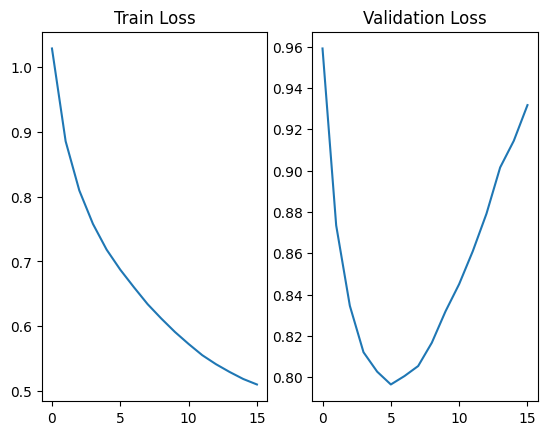

In [15]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(train_losses)
ax2.plot(validation_losses)
ax1.title.set_text('Train Loss')
ax2.title.set_text('Validation Loss')
plt.show()

In [16]:
print("Loading Model: ", model_file)
model = create_model()
model.load_state_dict(torch.load(save_path + model_file))
if torch.cuda.is_available():
    model = model.cuda()

Loading Model:  model_items_5.pt


In [17]:
def evaluation():
    model.eval()
    ys,y_hats, hits, hit_rates, criterion_eval = [], [], [], [], []
    
    for i, (input_vector_batch, result_vector_batch) in enumerate(test_dataloader):
        if torch.cuda.is_available():
            input_vector_batch, result_vector_batch = input_vector_batch.cuda(), result_vector_batch.cuda()
        
        out = model(input_vector_batch)
    
        for prediction_vector, result_vector in zip(out, result_vector_batch):
            y = [node_encodings_rev[x.item()] for x in torch.topk(result_vector, k=7).indices]
            ys.append(sorted(y))
            
            y_hat = [node_encodings_rev[x.item()] for x in torch.topk(prediction_vector, k=7).indices] 
            y_hats.append(sorted(y_hat))
        
            hit = [item for item in y if item in y_hat]
            
            hits.append(hit)
            hit_rates.append(len(hit) / 7)
        
    return {"y": ys, "y_hat": y_hats, "hit": hits, "hit_rate": hit_rates} #, "criterion_eval": criterion_eval


eval_results = evaluation()
df_eval_results = pd.DataFrame(eval_results)

print(f"Average Hit Rate: {df_eval_results['hit_rate'].mean()}%", )

df_eval_results

Average Hit Rate: 0.4911278195488722%


,y,y_hat,hit,hit_rate
0,"[Item_Blasting Wand, Item_Doran's Shield, Item...","[Item_Black Cleaver, Item_Farsight Alteration,...","[Item_Plated Steelcaps, Item_NO ITEM, Item_Ste...",0.428571
1,"[Item_Edge of Night, Item_Farsight Alteration,...","[Item_Berserker's Greaves, Item_Bloodthirster,...",[Item_Farsight Alteration],0.142857
2,"[Item_Amplifying Tome, Item_Blasting Wand, Ite...","[Item_Black Cleaver, Item_Farsight Alteration,...",[Item_Farsight Alteration],0.142857
3,"[Item_Aether Wisp, Item_Athene's Unholy Grail,...","[Item_Boots of Swiftness, Item_Control Ward, I...","[Item_Boots of Swiftness, Item_Oracle Lens]",0.285714
4,"[Item_Edge of Night, Item_Haunting Guise, Item...","[Item_Boots of Swiftness, Item_Edge of Night, ...","[Item_Oracle Lens, Item_Edge of Night, Item_Ha...",0.428571
...,...,...,...,...
470,"[Item_Berserker's Greaves, Item_Executioner's ...","[Item_Berserker's Greaves, Item_Black Cleaver,...",[Item_Berserker's Greaves],0.142857
471,"[Item_Corrupting Potion, Item_Hextech Rocketbe...","[Item_Blasting Wand, Item_Hextech Rocketbelt, ...","[Item_Hextech Rocketbelt, Item_Zhonya's Hourgl...",0.428571
472,"[Item_Control Ward, Item_Hextech GLP-800, Item...","[Item_Boots of Swiftness, Item_Bulwark of the ...","[Item_Oracle Lens, Item_Control Ward]",0.285714
473,"[Item_Control Ward, Item_Enchantment: Runic Ec...","[Item_Control Ward, Item_Enchantment: Runic Ec...","[Item_Enchantment: Runic Echoes, Item_Morellon...",1.000000
